📊 DATASET
    Study_Hours  Attendance
0           1.0          50
1           1.5          52
2           2.0          55
3           2.5          58
4           3.0          60
5           4.0          65
6           6.0          80
7           6.5          82
8           7.0          85
9           7.5          87
10          8.0          90
11          9.0          95


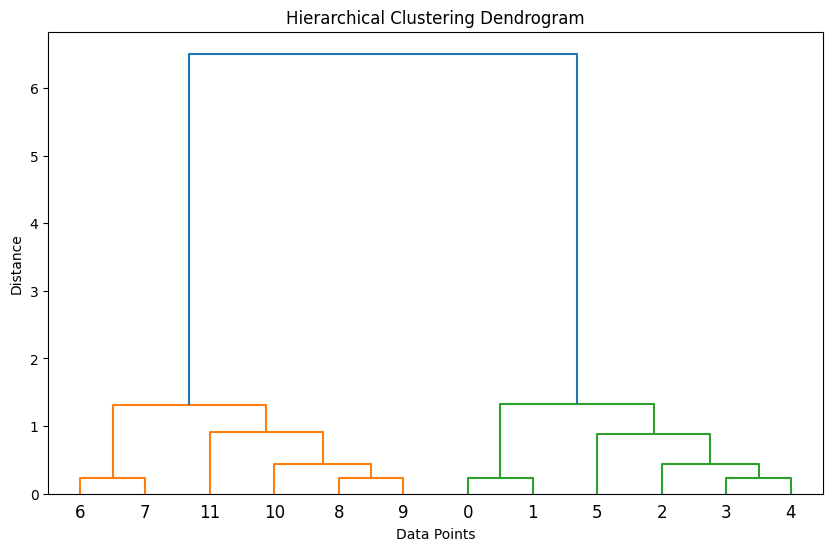


🌳 HIERARCHICAL CLUSTERING COMPLETED!

📌 CLUSTERED DATA
    Study_Hours  Attendance  Cluster
0           1.0          50        2
1           1.5          52        2
2           2.0          55        1
3           2.5          58        1
4           3.0          60        1
5           4.0          65        1
6           6.0          80        0
7           6.5          82        0
8           7.0          85        0
9           7.5          87        0
10          8.0          90        0
11          9.0          95        0


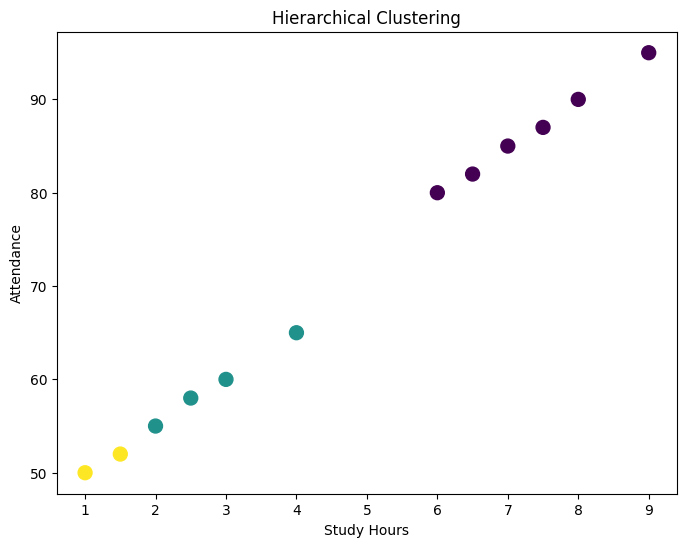

In [1]:
# 🌳 Day 25 - Hierarchical Clustering

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# 1. Create Dataset
data = {
    "Study_Hours": [1, 1.5, 2, 2.5, 3, 4, 6, 6.5, 7, 7.5, 8, 9],
    "Attendance": [50, 52, 55, 58, 60, 65, 80, 82, 85, 87, 90, 95]
}

df = pd.DataFrame(data)

print("📊 DATASET")
print(df)

# 2. Select Features
X = df[["Study_Hours", "Attendance"]]

# 3. Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Create Dendrogram
linked = linkage(X_scaled, method="ward")

plt.figure(figsize=(10, 6))

dendrogram(
    linked,
    labels=df.index.astype(str).tolist()
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

# 5. Create Agglomerative Clustering Model
model = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

# 6. Create Clusters
df["Cluster"] = model.fit_predict(X_scaled)

print("\n🌳 HIERARCHICAL CLUSTERING COMPLETED!")

print("\n📌 CLUSTERED DATA")
print(df)

# 7. Visualize Clusters
plt.figure(figsize=(8, 6))

plt.scatter(
    df["Study_Hours"],
    df["Attendance"],
    c=df["Cluster"],
    s=100
)

plt.xlabel("Study Hours")
plt.ylabel("Attendance")
plt.title("Hierarchical Clustering")
plt.show()